# 04 - Modeling: Classification & Regression
## Phân lớp lỗi/không lỗi + Hồi quy Tool wear + Time Series

### Pipeline:
1. **Classification:** Phân lớp Machine failure (binary, imbalanced)
   - Baselines: Logistic Regression, Random Forest
   - Cải tiến: Gradient Boosting, XGBoost, LightGBM  
   - Metrics: F1, PR-AUC, ROC-AUC
2. **Regression:** Dự đoán Tool wear [min]
   - Models: Linear, RF, GBR, XGBoost
   - Metrics: MAE, RMSE, R²
3. **Time Series:** ARIMA + Lag-features regression (UDI ≈ time index)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.data.loader import load_params
from src.models.supervised import SupervisedTrainer
from src.models.forecasting import TimeSeriesForecaster
from src.evaluation.metrics import (
    classification_metrics, regression_metrics,
    get_confusion_matrix_df, get_classification_report_df, error_analysis
)
from src.visualization.plots import (
    plot_confusion_matrix, plot_roc_curves, plot_precision_recall_curves,
    plot_feature_importance, plot_model_comparison, plot_residuals, save_fig
)

params = load_params('../configs/params.yaml')
np.random.seed(params['seed'])
print('Config loaded ✓')

Config loaded ✓


In [2]:
# Load processed data
df = pd.read_parquet('../data/processed/ai4i2020_processed.parquet')

with open('../data/processed/feature_info.json', 'r') as f:
    feature_info = json.load(f)

feature_cols = feature_info['feature_cols']
target_col = feature_info['target_col']

print(f'Data shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Target: {target_col}')
print(f'Failure rate: {df[target_col].mean()*100:.2f}%')

Data shape: (10000, 77)
Features: 69
Target: Machine failure
Failure rate: 3.39%


---
## 1. Classification: Machine Failure (Binary, Imbalanced)

In [3]:
# 1.1 Prepare data
X = df[feature_cols].values
y = df[target_col].values

# QUAN TRỌNG: Stratified split để giữ tỷ lệ failure
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=params['preprocessing']['test_size'],
    random_state=params['seed'], stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')
print(f'Train failure rate: {y_train.mean()*100:.2f}%')
print(f'Test failure rate: {y_test.mean()*100:.2f}%')

Train: (8000, 69), Test: (2000, 69)
Train failure rate: 3.39%
Test failure rate: 3.40%


In [4]:
# 1.2 Train all classifiers
trainer = SupervisedTrainer(params)
clf_results = trainer.train_classifiers(
    X_train_scaled, y_train, X_test_scaled, y_test, feature_cols
)

print('\n=== CLASSIFICATION RESULTS ===')
display(clf_results)
clf_results.to_csv('../outputs/tables/classification_results.csv', index=False)


[supervised] Training logistic_regression...


  → F1=0.3183, ROC-AUC=0.9264, PR-AUC=0.4056, Time=0.19s

[supervised] Training random_forest...


  → F1=0.7619, ROC-AUC=0.9687, PR-AUC=0.7949, Time=0.58s

[supervised] Training gradient_boosting...


  → F1=0.8413, ROC-AUC=0.9569, PR-AUC=0.8461, Time=24.92s

[supervised] Training xgboost...


  → F1=0.7971, ROC-AUC=0.9618, PR-AUC=0.8775, Time=0.91s

[supervised] Training lightgbm...


  → F1=0.8082, ROC-AUC=0.9567, PR-AUC=0.8896, Time=3.20s

[supervised] Best classifier: gradient_boosting

=== CLASSIFICATION RESULTS ===


,model,f1,roc_auc,pr_auc,precision,recall,train_time_s
2,gradient_boosting,0.8413,0.9569,0.8461,0.9138,0.7794,24.92
4,lightgbm,0.8082,0.9567,0.8896,0.7564,0.8676,3.20
3,xgboost,0.7971,0.9618,0.8775,0.7857,0.8088,0.91
1,random_forest,0.7619,0.9687,0.7949,0.8276,0.7059,0.58
0,logistic_regression,0.3183,0.9264,0.4056,0.1942,0.8824,0.19


In [5]:
# 1.3 Cross-validation
cv_results = trainer.cross_validate(X_train_scaled, y_train, cv=5)
print('\n=== CROSS-VALIDATION RESULTS ===')
display(cv_results)
cv_results.to_csv('../outputs/tables/cv_results.csv', index=False)

[supervised] logistic_regression CV F1: 0.3082 ± 0.0178


[supervised] random_forest CV F1: 0.6901 ± 0.0373


[supervised] gradient_boosting CV F1: 0.8560 ± 0.0182


[supervised] xgboost CV F1: 0.7980 ± 0.0270


[supervised] lightgbm CV F1: 0.7741 ± 0.0240

=== CROSS-VALIDATION RESULTS ===


,model,cv_f1_mean,cv_f1_std
0,logistic_regression,0.3082,0.0178
1,random_forest,0.6901,0.0373
2,gradient_boosting,0.8560,0.0182
3,xgboost,0.7980,0.0270
4,lightgbm,0.7741,0.0240


[plots] Saved: ../outputs/figures\04_model_comparison.png


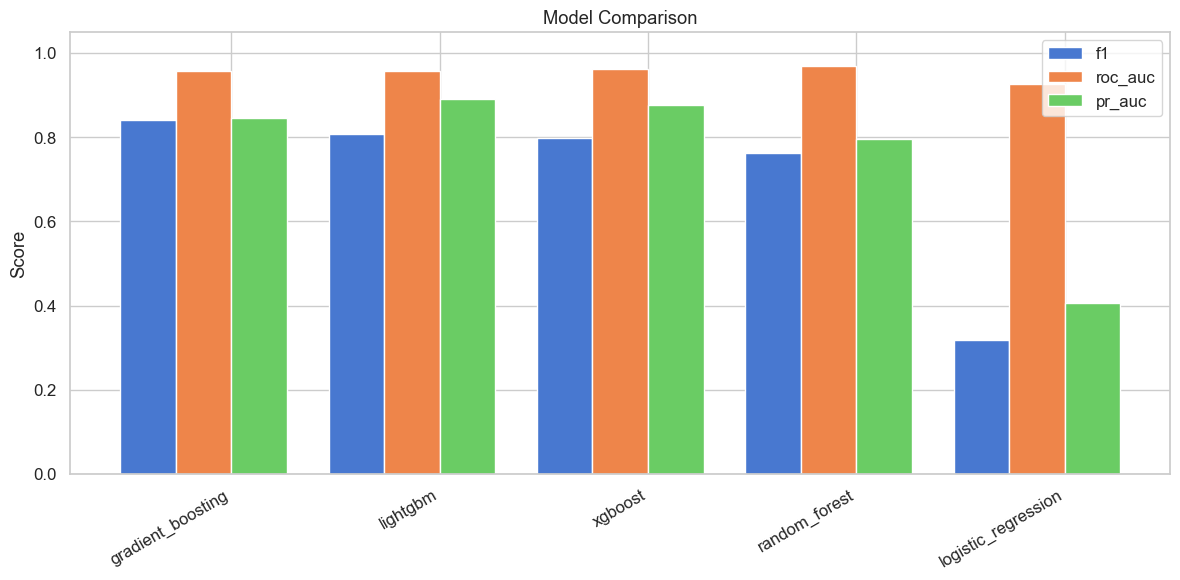

In [6]:
# 1.4 Model comparison visualization
fig = plot_model_comparison(clf_results, metric_cols=['f1', 'roc_auc', 'pr_auc'])
save_fig(fig, '04_model_comparison', '../outputs/figures')
plt.show()

[plots] Saved: ../outputs/figures\04_confusion_matrix_gradient_boosting.png

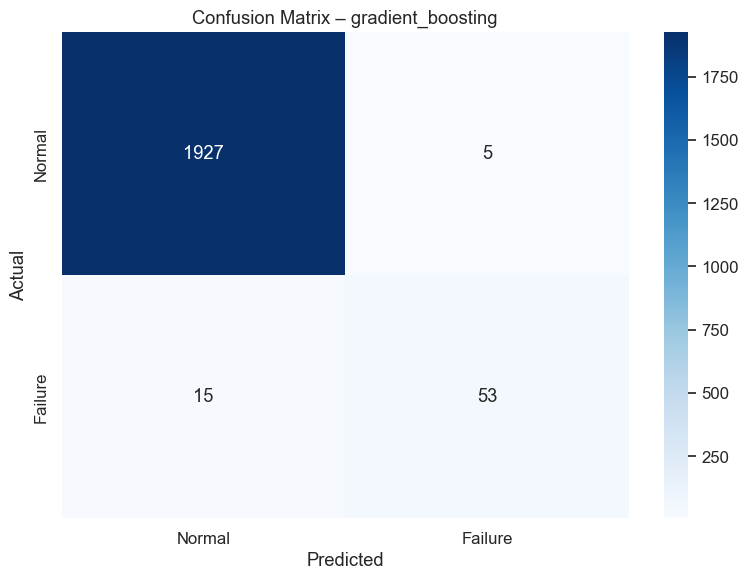

,precision,recall,f1-score,support
Normal,0.992276,0.997412,0.994837,1932.00
Failure,0.913793,0.779412,0.841270,68.00
accuracy,0.990000,0.990000,0.990000,0.99
macro avg,0.953035,0.888412,0.918054,2000.00
weighted avg,0.989608,0.990000,0.989616,2000.00


In [7]:
# 1.5 Confusion Matrix cho best model
best_name = trainer.best_model_name
best_result = trainer.results[best_name]

fig = plot_confusion_matrix(y_test, best_result['y_pred'], 
                            title=f'Confusion Matrix – {best_name}')
save_fig(fig, f'04_confusion_matrix_{best_name}', '../outputs/figures')
plt.show()

# Classification report
report_df = get_classification_report_df(y_test, best_result['y_pred'])
display(report_df)

[plots] Saved: ../outputs/figures\04_roc_curves.png


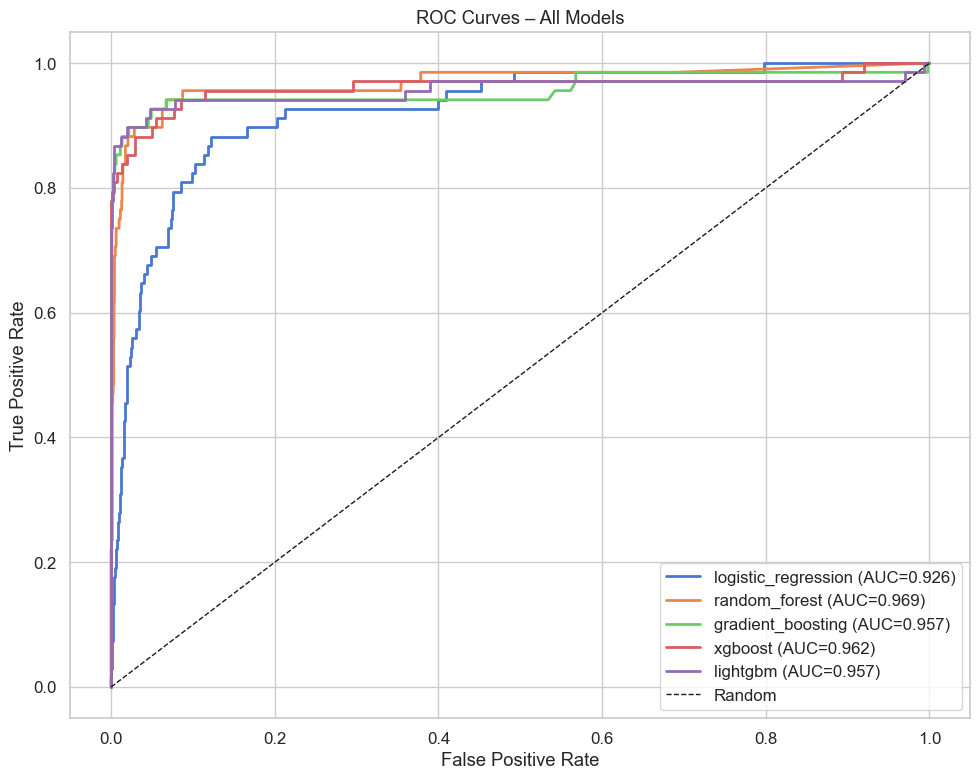

[plots] Saved: ../outputs/figures\04_pr_curves.png


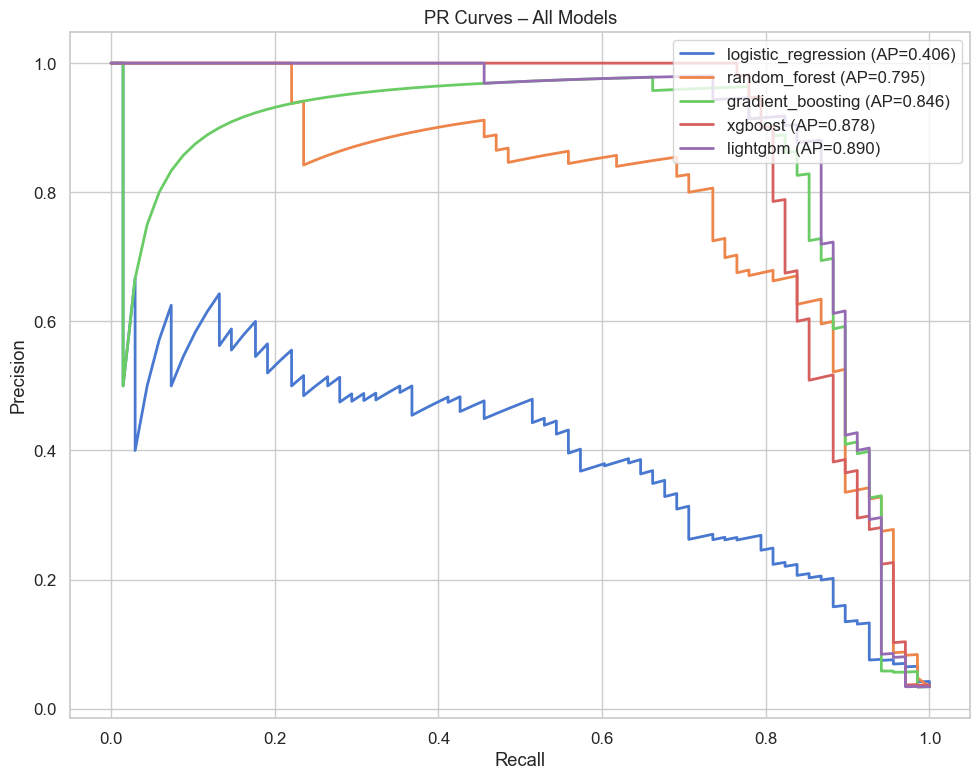

In [8]:
# 1.6 ROC & PR Curves
roc_data = {}
for name, res in trainer.results.items():
    if 'y_prob' in res and res['y_prob'] is not None:
        roc_data[name] = {'y_true': y_test, 'y_prob': res['y_prob']}

fig = plot_roc_curves(roc_data, title='ROC Curves – All Models')
save_fig(fig, '04_roc_curves', '../outputs/figures')
plt.show()

fig = plot_precision_recall_curves(roc_data, title='PR Curves – All Models')
save_fig(fig, '04_pr_curves', '../outputs/figures')
plt.show()

[plots] Saved: ../outputs/figures\04_feature_importance_gradient_boosting.png


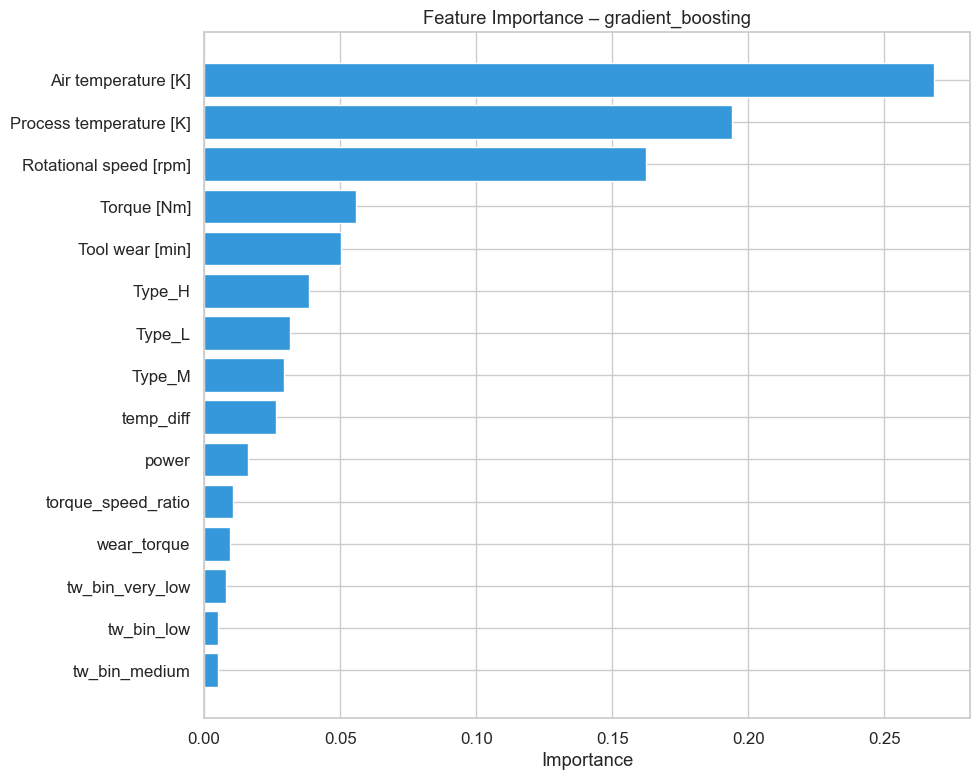

Top 10 features:


,feature,importance
11,Air temperature [K],0.268165
2,Process temperature [K],0.194152
9,Rotational speed [rpm],0.162489
8,Torque [Nm],0.055914
67,Tool wear [min],0.050257
6,Type_H,0.038594
3,Type_L,0.031618
68,Type_M,0.029270
10,temp_diff,0.026536
61,power,0.016288


In [9]:
# 1.7 Feature Importance
fi_df = trainer.get_feature_importance(best_name)
if len(fi_df) > 0 and len(feature_cols) == len(fi_df):
    fi_df['feature'] = feature_cols
    fi_df = fi_df.sort_values('importance', ascending=False)
    
    fig = plot_feature_importance(fi_df, top_n=15, title=f'Feature Importance – {best_name}')
    save_fig(fig, f'04_feature_importance_{best_name}', '../outputs/figures')
    plt.show()
    
    print('Top 10 features:')
    display(fi_df.head(10))

In [10]:
# 1.8 Error Analysis
err_analysis = error_analysis(y_test, best_result['y_pred'])
print(f'=== ERROR ANALYSIS – {best_name} ===')
for k, v in err_analysis.items():
    if not isinstance(v, list):
        print(f'  {k}: {v}')

# Phân tích false positives/negatives
print(f'\nFalse Positives (false alarm): {err_analysis["false_positives"]}')
print(f'False Negatives (missed failure): {err_analysis["false_negatives"]}')
print(f'False Alarm Rate: {err_analysis["false_alarm_rate"]:.4f}')
print(f'Miss Rate: {err_analysis["miss_rate"]:.4f}')

=== ERROR ANALYSIS – gradient_boosting ===
  true_negatives: 1927
  false_positives: 5
  false_negatives: 15
  true_positives: 53
  false_positive_rate: 0.0026
  false_negative_rate: 0.2206
  false_alarm_rate: 0.0026
  miss_rate: 0.2206

False Positives (false alarm): 5
False Negatives (missed failure): 15
False Alarm Rate: 0.0026
Miss Rate: 0.2206


In [11]:
# 1.9 Phân tích lỗi theo loại lỗi
failure_types = params['data']['failure_types']
print('=== PHÂN TÍCH LỖI THEO LOẠI ===')

# Dùng test indices
_, test_indices = train_test_split(
    np.arange(len(df)), test_size=params['preprocessing']['test_size'],
    random_state=params['seed'], stratify=y
)

df_test = df.iloc[test_indices].copy()
df_test['predicted'] = best_result['y_pred']

for ft in failure_types:
    ft_mask = df_test[ft] == 1
    if ft_mask.sum() == 0:
        continue
    ft_detected = (df_test.loc[ft_mask, 'predicted'] == 1).sum()
    ft_total = ft_mask.sum()
    print(f'  {ft}: {ft_detected}/{ft_total} detected ({ft_detected/ft_total*100:.1f}%)')

# Save model
trainer.save_model(best_name, f'../outputs/models/{best_name}.pkl')

=== PHÂN TÍCH LỖI THEO LOẠI ===
  TWF: 1/10 detected (10.0%)
  HDF: 25/29 detected (86.2%)
  PWF: 13/13 detected (100.0%)
  OSF: 16/16 detected (100.0%)
  RNF: 0/4 detected (0.0%)
[supervised] Saved gradient_boosting to ../outputs/models/gradient_boosting.pkl


---
## 2. Regression: Dự đoán Tool wear [min]

In [12]:
# 2.1 Prepare regression data
# Target = Tool wear [min], Features = sensor features (trừ Tool wear)
reg_target = 'Tool wear [min]'
reg_features = [c for c in feature_cols if reg_target not in c and 'tw_bin' not in c and 'wear' not in c.lower()]

X_reg = df[reg_features].values
y_reg = df[reg_target].values

# Chia theo thứ tự quan sát (temporal) cho regression
n_train = int(len(df) * 0.8)
X_reg_train, X_reg_test = X_reg[:n_train], X_reg[n_train:]
y_reg_train, y_reg_test = y_reg[:n_train], y_reg[n_train:]

# Scale
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

print(f'Regression Train: {X_reg_train_scaled.shape}')
print(f'Regression Test: {X_reg_test_scaled.shape}')
print(f'Target range: [{y_reg.min()}, {y_reg.max()}]')

Regression Train: (8000, 52)
Regression Test: (2000, 52)
Target range: [0, 253]


In [13]:
# 2.2 Train regressors
reg_trainer = SupervisedTrainer(params)
reg_results = reg_trainer.train_regressors(
    X_reg_train_scaled, y_reg_train,
    X_reg_test_scaled, y_reg_test
)

print('\n=== REGRESSION RESULTS ===')
display(reg_results)
reg_results.to_csv('../outputs/tables/regression_results.csv', index=False)


[supervised] Training regressor: linear_regression...
  → MAE=56.4628, RMSE=65.0867, R²=-0.0637

[supervised] Training regressor: random_forest_reg...


  → MAE=55.8199, RMSE=64.9568, R²=-0.0594

[supervised] Training regressor: gradient_boosting_reg...


  → MAE=55.8839, RMSE=65.6701, R²=-0.0828

[supervised] Training regressor: xgboost_reg...


  → MAE=56.6042, RMSE=66.9258, R²=-0.1246

=== REGRESSION RESULTS ===


,model,MAE,RMSE,R2,train_time_s
1,random_forest_reg,55.8199,64.9568,-0.0594,3.43
0,linear_regression,56.4628,65.0867,-0.0637,0.01
2,gradient_boosting_reg,55.8839,65.6701,-0.0828,18.53
3,xgboost_reg,56.6042,66.9258,-0.1246,0.34


[plots] Saved: ../outputs/figures\04_residuals_random_forest_reg.png


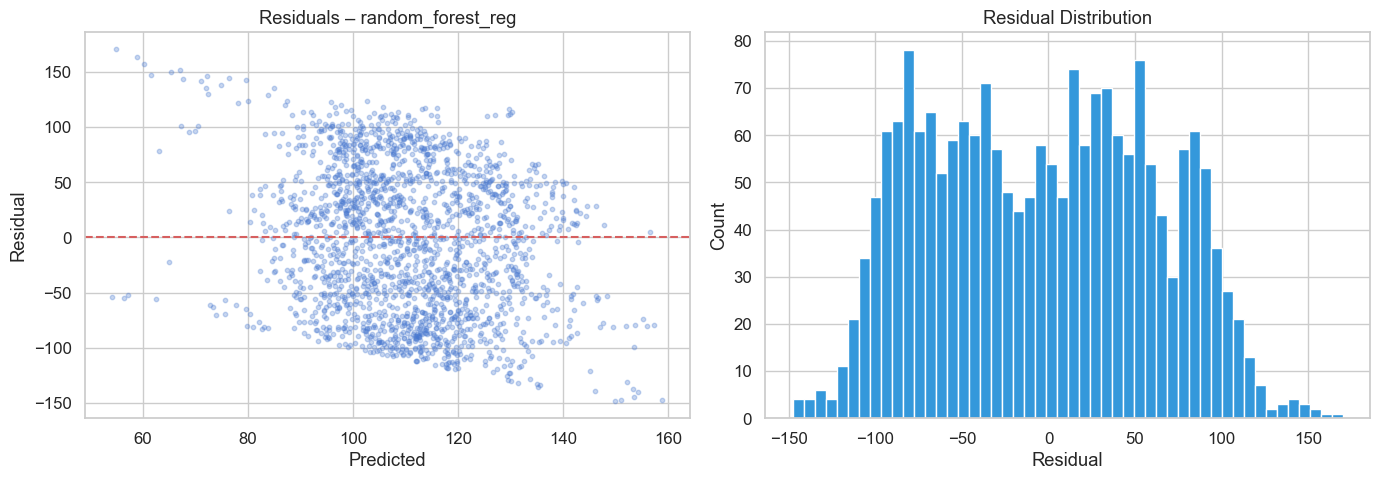

[plots] Saved: ../outputs/figures\04_actual_vs_predicted_random_forest_reg.png


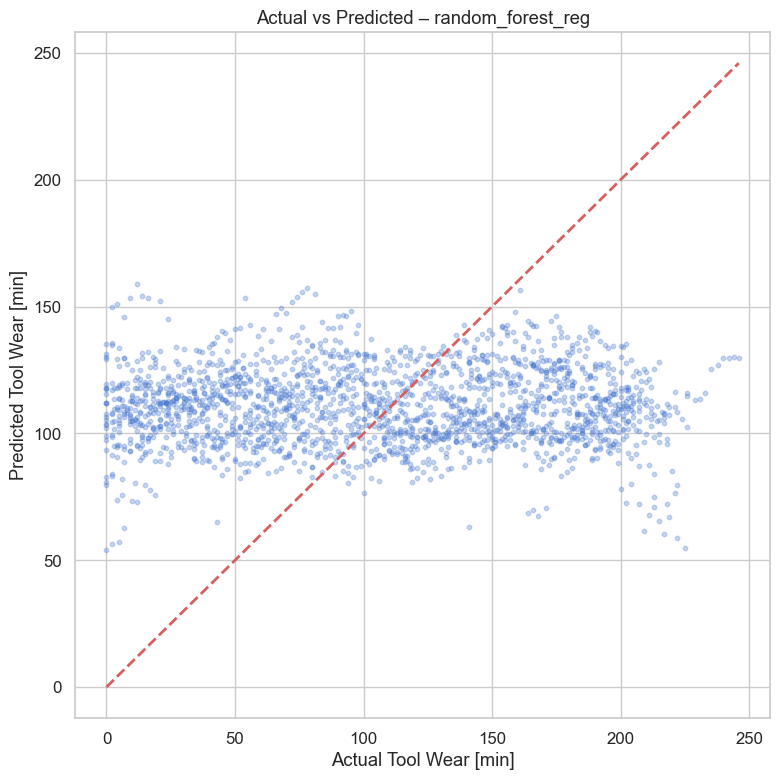

In [14]:
# 2.3 Residual analysis cho best regressor
best_reg = reg_results.iloc[0]['model']
y_reg_pred = reg_trainer.results[best_reg]['y_pred']

fig = plot_residuals(y_reg_test, y_reg_pred, title=f'Residuals – {best_reg}')
save_fig(fig, f'04_residuals_{best_reg}', '../outputs/figures')
plt.show()

# Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_reg_test, y_reg_pred, alpha=0.3, s=10)
ax.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', linewidth=2)
ax.set_xlabel('Actual Tool Wear [min]')
ax.set_ylabel('Predicted Tool Wear [min]')
ax.set_title(f'Actual vs Predicted – {best_reg}')
plt.tight_layout()
save_fig(fig, f'04_actual_vs_predicted_{best_reg}', '../outputs/figures')
plt.show()

---
## 3. Time Series: ARIMA + Lag Features

**Giả định:** UDI ≈ time index (dataset không có timestamp thực). Chia train/test theo thứ tự quan sát.

In [15]:
# 3.1 Time series setup
forecaster = TimeSeriesForecaster(params)
train_ts, test_ts = forecaster.temporal_train_test_split(df, 'Tool wear [min]', 0.8)

print(f'Train: {len(train_ts)}, Test: {len(test_ts)}')

[forecasting] Temporal split: train=8000, test=2000
Train: 8000, Test: 2000


In [16]:
# 3.2 ARIMA
arima_result = forecaster.fit_arima(
    train_ts['Tool wear [min]'],
    test_ts['Tool wear [min]'],
    order=(2, 1, 2)
)
if arima_result:
    print('\nARIMA Results:')
    for k, v in arima_result.items():
        print(f'  {k}: {v}')

[forecasting] Fitting ARIMA(2, 1, 2)...


[forecasting] ARIMA MAE=54.5115, RMSE=62.9723

ARIMA Results:
  model: ARIMA(2, 1, 2)
  MAE: 54.5115
  RMSE: 62.9723
  AIC: 73044.33
  BIC: 73079.26


In [17]:
# 3.3 Lag-features regression
# Dùng các lag/rolling features đã tạo
lag_feature_cols = [c for c in feature_cols if 'lag' in c or 'rmean' in c or 'rstd' in c
                    or c in ['Air temperature [K]', 'Process temperature [K]', 
                            'Rotational speed [rpm]', 'Torque [Nm]']]
lag_feature_cols = [c for c in lag_feature_cols if 'Tool wear' not in c and 'wear' not in c.lower()]

if len(lag_feature_cols) > 0:
    lag_result = forecaster.fit_lag_regression(
        train_ts, test_ts, 'Tool wear [min]', lag_feature_cols
    )
    print('\nLag Regression Results:')
    for k, v in lag_result.items():
        print(f'  {k}: {v}')
else:
    print('No lag features available. Run feature engineering with lag features enabled.')

[forecasting] Lag Regression MAE=56.4640, RMSE=66.4035, R²=-0.1071

Lag Regression Results:
  model: GBR_lag_features
  MAE: 56.464
  RMSE: 66.4035
  R2: -0.1071



=== TIME SERIES COMPARISON ===


,model,MAE,RMSE,AIC,BIC,R2
0,"ARIMA(2, 1, 2)",54.5115,62.9723,73044.33,73079.26,NaN
1,GBR_lag_features,56.4640,66.4035,NaN,NaN,-0.1071


[plots] Saved: ../outputs/figures\04_arima_forecast.png


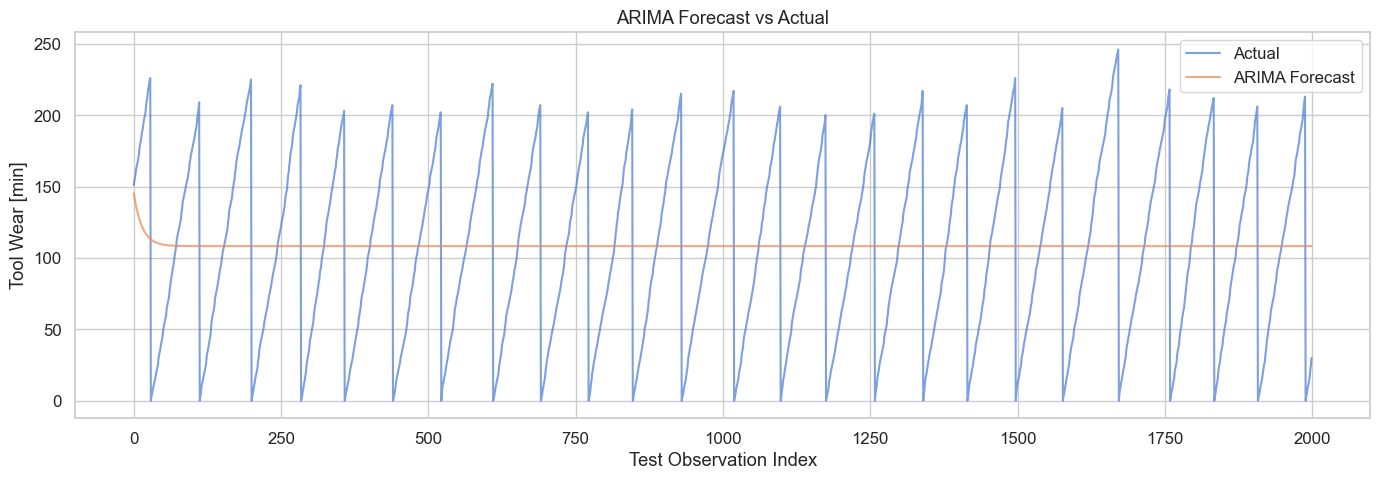

In [18]:
# 3.4 Time series comparison
ts_results = forecaster.get_results_table()
if len(ts_results) > 0:
    print('\n=== TIME SERIES COMPARISON ===')
    display(ts_results)
    ts_results.to_csv('../outputs/tables/timeseries_results.csv', index=False)

    # Plot forecast vs actual
    if 'arima' in forecaster.results:
        ar = forecaster.results['arima']
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(range(len(ar['actual'])), ar['actual'], label='Actual', alpha=0.7)
        ax.plot(range(len(ar['forecast'])), ar['forecast'], label='ARIMA Forecast', alpha=0.7)
        ax.set_xlabel('Test Observation Index')
        ax.set_ylabel('Tool Wear [min]')
        ax.set_title('ARIMA Forecast vs Actual')
        ax.legend()
        plt.tight_layout()
        save_fig(fig, '04_arima_forecast', '../outputs/figures')
        plt.show()

---
## 4. Tóm tắt Modeling

### Classification:
- So sánh 5 models (2 baselines + 3 cải tiến)
- Xử lý imbalance bằng class_weight/scale_pos_weight
- đánh giá bằng F1, PR-AUC (phù hợp cho imbalanced)

### Regression:
- Dự đoán Tool wear, chia temporal
- MAE/RMSE/R² cho đánh giá

### Time Series:
- ARIMA với UDI ≈ time index (giả định)
- Lag-features regression outperform ARIMA